# Does whisking/licking follow the mouse across a change of rig?

Mice are trained on behaviour rigs and recorded on ephys rigs — different physical setups,
usually a different room. That makes a natural experiment out of the dataset:

- **if a mouse's measure transfers across the rig change, that is individuality** — a trait
  carried by the animal, not by the apparatus it was measured on
- **if the lab ordering is the same on both sets of rigs**, the lab effect in whisking and
  licking is not rig-specific, because the rigs changed underneath it

**Early and Late are kept separate.** Pooling them would buy statistical power at the cost of
mixing in a lot of learning — the animal at session 1 and at the end of training is not the
same behaving animal — so each is correlated against Proficient on its own.

**Attenuation.** A cross-rig correlation is capped by how reliable each measure is. For
licking especially — it has its own QC flags (`lick_detection`, "bad lick fit") and is the one
channel that tracks camera zoom — a low raw r could mean an unstable trait or a noisy
measurement. Correlations are reported raw and disattenuated. The training-side reliability
can only be estimated from Early vs Late, which **learning deflates**, so the disattenuated
values are upper bounds and are marked as such.

In [1]:
"""SETUP"""
import sys, pathlib, importlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

_p = pathlib.Path.cwd().resolve()
while not (_p / 'paper_style.py').exists() and _p != _p.parent:
    _p = _p.parent
for _sub in ['', '4_mice', 'learning_individuality', 'lab']:
    sys.path.insert(0, str(_p / _sub) if _sub else str(_p))
import paper_style as ps; importlib.reload(ps); ps.use('poster')
import variance_partition as vp; importlib.reload(vp)
import functions

FILES = {'Early': _p / 'data/training/paw_wheel_session_1_8_k_10_bin_syllables_04-09-2026',
         'Late':  _p / 'data/training/paw_wheel_last_training_8_k_10_bin_syllables_04-09-2026',
         'Proficient': _p / 'data/8_k_10_bin_syllables_19-08-2026'}
C_W, C_L = '#2F6B8F', '#B3472A'


def occupancy(f):
    """per-session whisk and lick occupancy. Stored syllable code = paw + 8*whisk + 16*lick,
    so the two binary digits come straight out by integer arithmetic -- no dict round-trip."""
    d = pd.read_parquet(f)
    d['session'] = d['sample'].str[:36]
    a = np.stack(d['binned_sequence'].to_numpy())
    whisk = np.floor_divide(a, 8) % 2
    lick = np.floor_divide(a, 16)
    out = pd.DataFrame({'session': d['session'].to_numpy(), 'mouse': d['mouse_name'].to_numpy(),
                        'whisk': np.nanmean(whisk, axis=1), 'lick': np.nanmean(lick, axis=1)})
    return out.groupby(['session', 'mouse'], as_index=False)[['whisk', 'lick']].mean()


S = {k: occupancy(v) for k, v in FILES.items()}
for k, v in S.items():
    print(f'{k:11s} {len(v):4d} sessions  {v.mouse.nunique():3d} mice   '
          f'whisk {v.whisk.mean():.3f}  lick {v.lick.mean():.3f}')

PROF = S['Proficient'].assign(tp='Proficient')

# LAB COMES FROM THE MOUSE, NOT THE SESSION. A training session can sit on a rig owned by a
# different lab than the ephys rig (SWC_060 is one), and functions.lab_labels rightly refuses
# to map a mouse to two labs. The animal's lab is taken from its PROFICIENT sessions and used
# at every timepoint, which is also the labelling the rest of the project uses.
_ses = pd.Index(PROF['session'])
_lab_prof = functions.lab_labels(_ses, mouse_names=pd.Series(PROF['mouse'].values, index=_ses),
                                 verbose=False)
MOUSE_LAB = pd.Series(_lab_prof.values, index=PROF['mouse'].values).groupby(level=0).first()
print(f'\nlab assigned per MOUSE from its proficient sessions: {MOUSE_LAB.nunique()} labs, '
      f'{len(MOUSE_LAB)} mice')

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi


/tmp/ipykernel_65775/3653300225.py:31: RuntimeWarning: Mean of empty slice
  'whisk': np.nanmean(whisk, axis=1), 'lick': np.nanmean(lick, axis=1)})
/tmp/ipykernel_65775/3653300225.py:31: RuntimeWarning: Mean of empty slice
  'whisk': np.nanmean(whisk, axis=1), 'lick': np.nanmean(lick, axis=1)})


Early         47 sessions   47 mice   whisk 0.654  lick 0.132
Late          55 sessions   55 mice   whisk 0.634  lick 0.166
Proficient   332 sessions  101 mice   whisk 0.585  lick 0.195

lab assigned per MOUSE from its proficient sessions: 10 labs, 101 mice


/tmp/ipykernel_65775/3653300225.py:31: RuntimeWarning: Mean of empty slice
  'whisk': np.nanmean(whisk, axis=1), 'lick': np.nanmean(lick, axis=1)})


## 1. How reliable is each measure, within a timepoint?

This sets the ceiling for everything that follows. Training reliability is the Early-vs-Late
correlation across mice; proficient reliability is a split-half over each mouse's sessions.

In [2]:
"""RELIABILITY -- the ceiling on any cross-rig correlation"""
rel = {}
e = S['Early'].set_index('mouse'); l = S['Late'].set_index('mouse')
both = e.index.intersection(l.index)
for m in ['whisk', 'lick']:
    rel[('training', m)] = stats.pearsonr(e.loc[both, m], l.loc[both, m])[0]
for m in ['whisk', 'lick']:
    a, b = [], []
    for mouse, g in PROF.groupby('mouse'):
        if len(g) < 4:
            continue
        g = g.sample(frac=1, random_state=0)
        a.append(g[m].iloc[::2].mean()); b.append(g[m].iloc[1::2].mean())
    r = stats.pearsonr(a, b)[0]
    rel[('proficient', m)] = 2 * r / (1 + r)      # Spearman-Brown to the full session count
print(f'training-side reliability from Early vs Late (n={len(both)} mice) -- A LOWER BOUND,')
print('because a lot of learning happens between those two sessions, which deflates it:')
for m in ['whisk', 'lick']:
    print(f'  {m:6s} r = {rel[("training", m)]:+.3f}')
print(f'\nproficient-side split-half reliability (n={len(a)} mice with >=4 sessions,'
      f' Spearman-Brown corrected):')
for m in ['whisk', 'lick']:
    print(f'  {m:6s} r = {rel[("proficient", m)]:+.3f}')

training-side reliability from Early vs Late (n=45 mice) -- A LOWER BOUND,
because a lot of learning happens between those two sessions, which deflates it:
  whisk  r = +0.365
  lick   r = +0.335

proficient-side split-half reliability (n=39 mice with >=4 sessions, Spearman-Brown corrected):
  whisk  r = +0.944
  lick   r = +0.910


## 2. Does the trait cross the rig change?

wrote figures/whisk_lick_across_rigs_poster_18-09-2026.png, figures/whisk_lick_across_rigs_poster_18-09-2026.svg


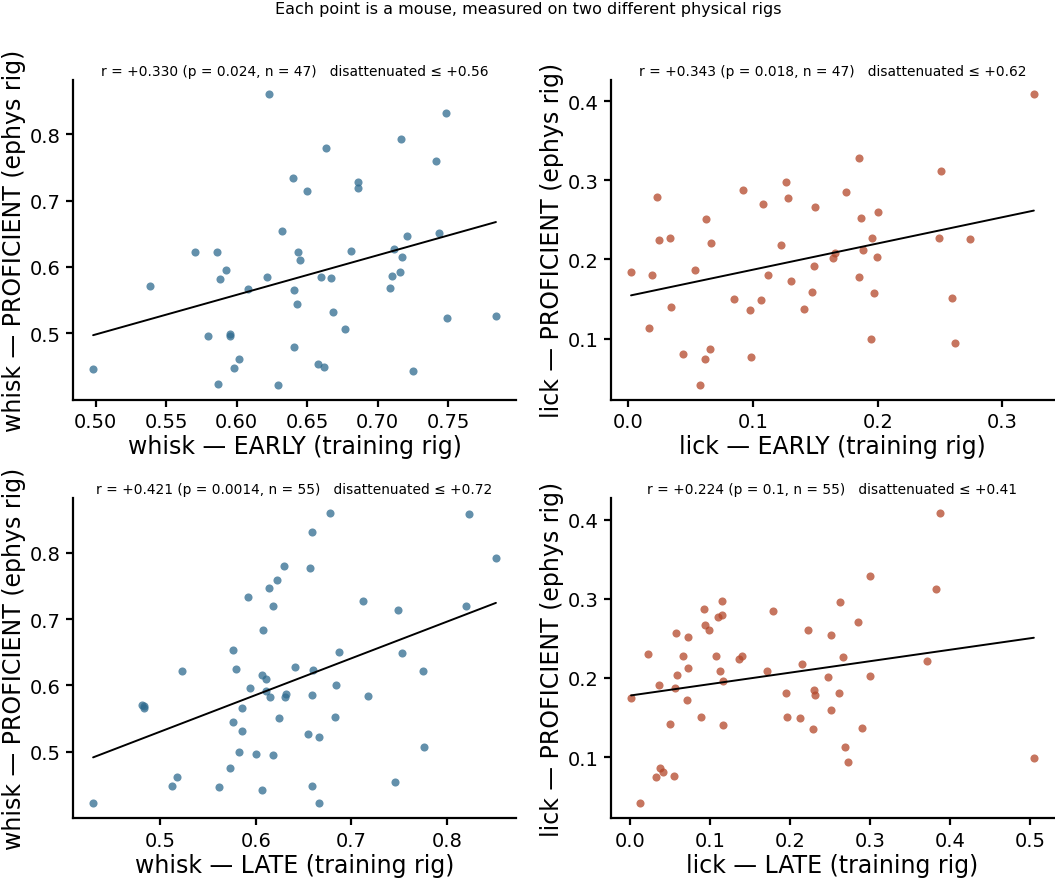

timepoint measure     r     p  n  disattenuated
    Early   whisk 0.330 0.024 47          0.562
    Early    lick 0.343 0.018 47          0.622
     Late   whisk 0.421 0.001 55          0.716
     Late    lick 0.224 0.101 55          0.405


In [3]:
"""CROSS-RIG CORRELATION -- Early and Late each against Proficient"""
pr = PROF.groupby('mouse')[['whisk', 'lick']].mean()
fig, axs = plt.subplots(2, 2, figsize=(11, 9))
rows = []
for row, tp in enumerate(['Early', 'Late']):
    tr = S[tp].groupby('mouse')[['whisk', 'lick']].mean()
    J = tr.join(pr, lsuffix='_tr', rsuffix='_pr').dropna()
    for col, (m, colr) in enumerate([('whisk', C_W), ('lick', C_L)]):
        ax = axs[row, col]
        x, y = J[f'{m}_tr'], J[f'{m}_pr']
        r = stats.pearsonr(x, y)
        dis = r[0] / np.sqrt(max(rel[('training', m)], .01) * max(rel[('proficient', m)], .01))
        ax.scatter(x, y, s=34, color=colr, alpha=.75, linewidths=0)
        lo, hi = x.min(), x.max()
        a_, b_ = np.polyfit(x, y, 1)
        ax.plot([lo, hi], [a_ * lo + b_, a_ * hi + b_], color='k', lw=1.4)
        ax.set_xlabel(f'{m} — {tp.upper()} (training rig)')
        ax.set_ylabel(f'{m} — PROFICIENT (ephys rig)')
        ax.set_title(f'r = {r[0]:+.3f} (p = {r[1]:.2g}, n = {len(J)})   '
                     f'disattenuated ≤ {min(dis, 1.0):+.2f}',
                     fontsize=plt.rcParams['font.size'] * 0.62)
        rows.append(dict(timepoint=tp, measure=m, r=r[0], p=r[1], n=len(J), disattenuated=dis))
fig.suptitle('Each point is a mouse, measured on two different physical rigs',
             fontsize=plt.rcParams['font.size'] * 0.72, y=1.0)
fig.tight_layout(); ps.savefig(fig, 'whisk_lick_across_rigs', svg=True); plt.show()
print(pd.DataFrame(rows).round(3).to_string(index=False))

## 3. Is the lab effect present on both sets of rigs, in the same direction?

At training each mouse has one or two sessions, so a nested lab/mouse/session model has almost
no within-mouse degrees of freedom. The test here is therefore at the **mouse level**: eta^2 of
the lab label on per-mouse means, against a null that shuffles lab across mice.

  Early       whisk  eta^2 0.370  null 0.197  p = 0.0262  (47 mice, 10 labs)


  Early       lick   eta^2 0.328  null 0.197  p = 0.0678  (47 mice, 10 labs)


  Late        whisk  eta^2 0.189  null 0.165  p = 0.3362  (55 mice, 10 labs)


  Late        lick   eta^2 0.435  null 0.167  p = 0.0018  (55 mice, 10 labs)


  Proficient  whisk  eta^2 0.223  null 0.090  p = 0.0042  (100 mice, 10 labs)


  Proficient  lick   eta^2 0.296  null 0.090  p = 0.0002  (100 mice, 10 labs)


wrote figures/lab_ordering_across_rigs_poster_18-09-2026.png, figures/lab_ordering_across_rigs_poster_18-09-2026.svg


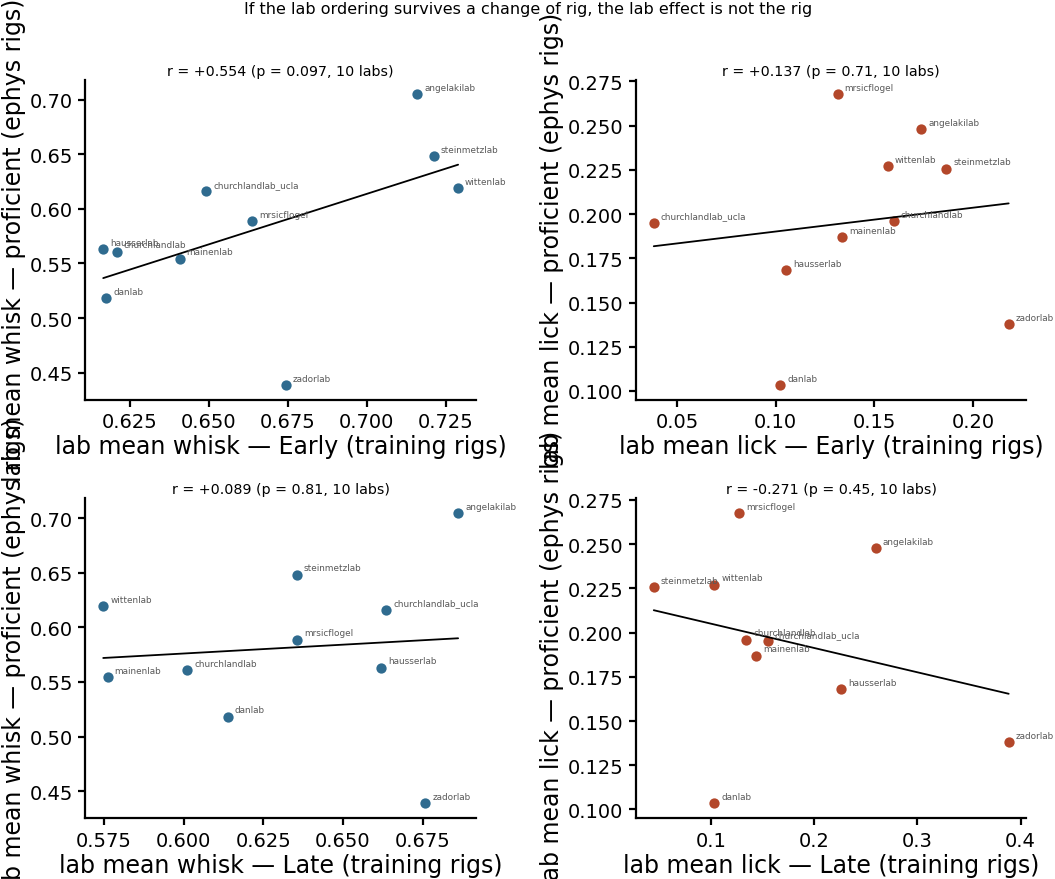

In [4]:
"""LAB EFFECT AT EACH TIMEPOINT, AND WHETHER THE ORDERING AGREES"""
sets = {'Early': S['Early'], 'Late': S['Late'], 'Proficient': PROF}
per_lab = {}
for nm, df in sets.items():
    d = df.copy()
    d['lab'] = d['mouse'].map(MOUSE_LAB)
    d = d.dropna(subset=['lab'])
    pmouse = d.groupby(['mouse', 'lab'], as_index=False)[['whisk', 'lick']].mean()
    for m in ['whisk', 'lick']:
        D = pmouse[[m]].set_index(pmouse['mouse'])
        o, null, pv = vp.permutation_null_eta2(D, pmouse['lab'].values, pmouse['mouse'].values,
                                               n_perm=5000, seed=0)
        print(f'  {nm:11s} {m:6s} eta^2 {o:.3f}  null {null.mean():.3f}  p = {pv:.4f}  '
              f'({pmouse.mouse.nunique()} mice, {pmouse.lab.nunique()} labs)')
    per_lab[nm] = pmouse.groupby('lab')[['whisk', 'lick']].mean()

fig, axs = plt.subplots(2, 2, figsize=(11, 9))
for row, tp in enumerate(['Early', 'Late']):
    T = per_lab[tp].join(per_lab['Proficient'], lsuffix='_tr', rsuffix='_pr').dropna()
    for col, (m, colr) in enumerate([('whisk', C_W), ('lick', C_L)]):
        ax = axs[row, col]
        r = stats.pearsonr(T[f'{m}_tr'], T[f'{m}_pr'])
        ax.scatter(T[f'{m}_tr'], T[f'{m}_pr'], s=55, color=colr, linewidths=0)
        for lab_name, rw in T.iterrows():
            ax.annotate(lab_name, (rw[f'{m}_tr'], rw[f'{m}_pr']), textcoords='offset points',
                        xytext=(5, 3), fontsize=plt.rcParams['font.size'] * 0.4, color='0.35')
        lo, hi = T[f'{m}_tr'].min(), T[f'{m}_tr'].max()
        a_, b_ = np.polyfit(T[f'{m}_tr'], T[f'{m}_pr'], 1)
        ax.plot([lo, hi], [a_ * lo + b_, a_ * hi + b_], color='k', lw=1.3)
        ax.set_xlabel(f'lab mean {m} — {tp} (training rigs)')
        ax.set_ylabel(f'lab mean {m} — proficient (ephys rigs)')
        ax.set_title(f'r = {r[0]:+.3f} (p = {r[1]:.2g}, {len(T)} labs)',
                     fontsize=plt.rcParams['font.size'] * 0.64)
fig.suptitle('If the lab ordering survives a change of rig, the lab effect is not the rig',
             fontsize=plt.rcParams['font.size'] * 0.72, y=1.0)
fig.tight_layout(); ps.savefig(fig, 'lab_ordering_across_rigs', svg=True); plt.show()

## Caveats

- **Early and Late are not two measurements of the same animal state.** A great deal of
  learning happens between them, so their correlation is a *lower bound* on training-side
  reliability, and every disattenuated value above is therefore an upper bound.
- **Licking is the weaker measurement.** It carries its own QC flags in the session sheet
  (`lick_detection`, "bad lick fit") and is the one channel that tracks camera zoom (raw
  `Lick count` r = −0.516 with nose-to-pupil). Read its cross-rig correlation against its own
  reliability, not against whisking's.
- **Training sessions are left-camera only**, so none of the two-camera controls used in the
  paw analyses are available here.
- **The task differs between timepoints**, so absolute levels are not comparable across rigs —
  only the per-mouse and per-lab *ordering*, which is what both tests use.
- **Mice are not randomly assigned to labs.** A lab effect that survives the rig change still
  cannot separate husbandry from provenance; it only rules out the apparatus.